In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import math

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ============================================
# Rosenbrock Function
# ============================================

a = 1
b = 100

def rosenbrock(x, y):
    """
    Rosenbrock function:
    f(x,y) = (a-x)^2 + b(y-x^2)^2
    """
    return (a - x)**2 + b * (y - x**2)**2


# Test the function at the known minimum
x = 1
y = 1

print("Rosenbrock value at (1,1):", rosenbrock(x, y))

Rosenbrock value at (1,1): 0


In [3]:
# ============================================
# Gradient of Rosenbrock Function
# ============================================

def rosenbrock_gradient(x, y):
    """
    Returns the gradient of the Rosenbrock function.

    df/dx = 2(x-1) - 400*x*(y-x^2)
    df/dy = 200*(y-x^2)
    """

    dx = 2 * (x - 1) - 400 * x * (y - x**2)
    dy = 200 * (y - x**2)

    return np.array([dx, dy])


# Test gradient at the minimum
gradient = rosenbrock_gradient(1, 1)

print("Gradient at (1,1):", gradient)

Gradient at (1,1): [0 0]


In [4]:
# ============================================
# Gradient Descent for Rosenbrock
# ============================================

def gradient_descent_rosenbrock(
    learning_rate,
    max_iterations=100000,
    tolerance=1e-8,
    x_start=-1.5,
    y_start=2.0
):

    x = x_start
    y = y_start

    history = []

    start_time = time.time()

    for iteration in range(max_iterations):

        # Calculate current function value
        loss = rosenbrock(x, y)

        # Store the loss
        history.append(loss)

        # Calculate gradient
        gradient = rosenbrock_gradient(x, y)

        # Check convergence
        if np.linalg.norm(gradient) < tolerance:
            break

        # Update x and y
        x = x - learning_rate * gradient[0]
        y = y - learning_rate * gradient[1]

    end_time = time.time()

    return {
        "x": x,
        "y": y,
        "function_value": rosenbrock(x, y),
        "iterations": iteration + 1,
        "time": end_time - start_time,
        "history": history
    }

In [5]:
# ============================================
# Test Gradient Descent
# ============================================

result = gradient_descent_rosenbrock(
    learning_rate=0.001
)

print("Optimal x:", result["x"])
print("Optimal y:", result["y"])
print("Final function value:", result["function_value"])
print("Iterations:", result["iterations"])
print("Time taken:", result["time"], "seconds")

Optimal x: 0.9999999888212429
Optimal y: 0.9999999775977529
Final function value: 1.25164714335569e-16
Iterations: 44219
Time taken: 0.48037075996398926 seconds


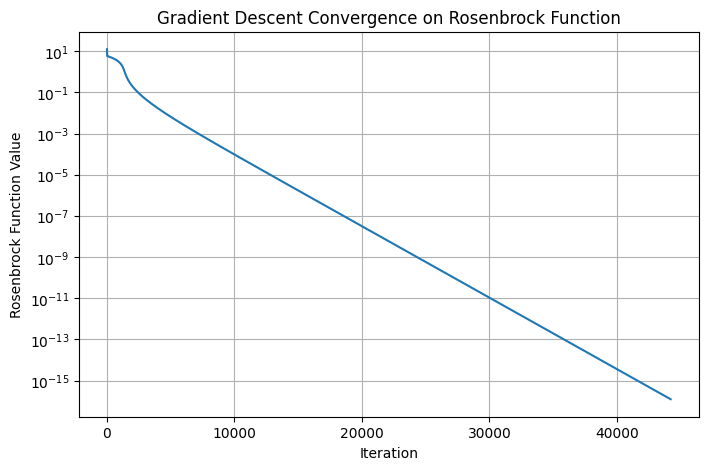

In [6]:
# ============================================
# Plot Gradient Descent Convergence
# ============================================

plt.figure(figsize=(8, 5))

plt.plot(result["history"])

plt.xlabel("Iteration")
plt.ylabel("Rosenbrock Function Value")
plt.title("Gradient Descent Convergence on Rosenbrock Function")

plt.yscale("log")
plt.grid(True)

plt.show()

In [7]:
# ============================================
# SGD with Momentum for Rosenbrock
# ============================================

def momentum_rosenbrock(
    learning_rate,
    beta=0.9,
    max_iterations=100000,
    tolerance=1e-8,
    x_start=-1.5,
    y_start=2.0
):

    x = x_start
    y = y_start

    # Initial velocity
    velocity = np.array([0.0, 0.0])

    history = []

    start_time = time.time()

    for iteration in range(max_iterations):

        # Current function value
        loss = rosenbrock(x, y)
        history.append(loss)

        # Calculate gradient
        gradient = rosenbrock_gradient(x, y)

        # Check convergence
        if np.linalg.norm(gradient) < tolerance:
            break

        # Update velocity
        velocity = beta * velocity + gradient

        # Update parameters
        x = x - learning_rate * velocity[0]
        y = y - learning_rate * velocity[1]

    end_time = time.time()

    return {
        "x": x,
        "y": y,
        "function_value": rosenbrock(x, y),
        "iterations": iteration + 1,
        "time": end_time - start_time,
        "history": history
    }

In [8]:
# ============================================
# Test Momentum
# ============================================

momentum_result = momentum_rosenbrock(
    learning_rate=0.001
)

print("Optimal x:", momentum_result["x"])
print("Optimal y:", momentum_result["y"])
print("Final function value:", momentum_result["function_value"])
print("Iterations:", momentum_result["iterations"])
print("Time taken:", momentum_result["time"], "seconds")

Optimal x: 0.9999999888269405
Optimal y: 0.9999999776091714
Final function value: 1.2503715463536877e-16
Iterations: 4226
Time taken: 0.0784463882446289 seconds


In [9]:
# ============================================
# Adam Optimizer for Rosenbrock
# ============================================

def adam_rosenbrock(
    learning_rate,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-8,
    max_iterations=100000,
    tolerance=1e-8,
    x_start=-1.5,
    y_start=2.0
):

    x = x_start
    y = y_start

    # First moment
    m = np.array([0.0, 0.0])

    # Second moment
    v = np.array([0.0, 0.0])

    history = []

    start_time = time.time()

    for iteration in range(1, max_iterations + 1):

        # Current function value
        loss = rosenbrock(x, y)
        history.append(loss)

        # Calculate gradient
        gradient = rosenbrock_gradient(x, y)

        # Check convergence
        if np.linalg.norm(gradient) < tolerance:
            break

        # Update biased first moment
        m = beta1 * m + (1 - beta1) * gradient

        # Update biased second moment
        v = beta2 * v + (1 - beta2) * (gradient ** 2)

        # Bias correction
        m_hat = m / (1 - beta1 ** iteration)
        v_hat = v / (1 - beta2 ** iteration)

        # Update parameters
        update = learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)

        x = x - update[0]
        y = y - update[1]

    end_time = time.time()

    return {
        "x": x,
        "y": y,
        "function_value": rosenbrock(x, y),
        "iterations": iteration,
        "time": end_time - start_time,
        "history": history
    }

In [10]:
# ============================================
# Test Adam
# ============================================

adam_result = adam_rosenbrock(
    learning_rate=0.001
)

print("Optimal x:", adam_result["x"])
print("Optimal y:", adam_result["y"])
print("Final function value:", adam_result["function_value"])
print("Iterations:", adam_result["iterations"])
print("Time taken:", adam_result["time"], "seconds")

Optimal x: 0.9999999899799523
Optimal y: 0.9999999799297439
Final function value: 1.0049232334972414e-16
Iterations: 12217
Time taken: 0.7356774806976318 seconds


In [11]:
# ============================================
# RMSprop Optimizer for Rosenbrock
# ============================================

def rmsprop_rosenbrock(
    learning_rate,
    beta=0.9,
    epsilon=1e-8,
    max_iterations=100000,
    tolerance=1e-8,
    x_start=-1.5,
    y_start=2.0
):

    x = x_start
    y = y_start

    # Moving average of squared gradients
    squared_gradient = np.array([0.0, 0.0])

    history = []

    start_time = time.time()

    for iteration in range(max_iterations):

        # Current function value
        loss = rosenbrock(x, y)
        history.append(loss)

        # Calculate gradient
        gradient = rosenbrock_gradient(x, y)

        # Check convergence
        if np.linalg.norm(gradient) < tolerance:
            break

        # Update moving average of squared gradients
        squared_gradient = (
            beta * squared_gradient
            + (1 - beta) * (gradient ** 2)
        )

        # Parameter update
        update = (
            learning_rate
            * gradient
            / (np.sqrt(squared_gradient) + epsilon)
        )

        x = x - update[0]
        y = y - update[1]

    end_time = time.time()

    return {
        "x": x,
        "y": y,
        "function_value": rosenbrock(x, y),
        "iterations": iteration + 1,
        "time": end_time - start_time,
        "history": history
    }

In [12]:
# ============================================
# Test RMSprop
# ============================================

rmsprop_result = rmsprop_rosenbrock(
    learning_rate=0.001
)

print("Optimal x:", rmsprop_result["x"])
print("Optimal y:", rmsprop_result["y"])
print("Final function value:", rmsprop_result["function_value"])
print("Iterations:", rmsprop_result["iterations"])
print("Time taken:", rmsprop_result["time"], "seconds")

Optimal x: 1.0003500149960056
Optimal y: 0.9992003025208132
Final function value: 0.00022507750725666133
Iterations: 100000
Time taken: 6.256960391998291 seconds


In [13]:
# ============================================
# Adagrad Optimizer for Rosenbrock
# ============================================

def adagrad_rosenbrock(
    learning_rate,
    epsilon=1e-8,
    max_iterations=100000,
    tolerance=1e-8,
    x_start=-1.5,
    y_start=2.0
):

    x = x_start
    y = y_start

    # Accumulated squared gradients
    accumulated_gradient = np.array([0.0, 0.0])

    history = []

    start_time = time.time()

    for iteration in range(max_iterations):

        # Current function value
        loss = rosenbrock(x, y)
        history.append(loss)

        # Calculate gradient
        gradient = rosenbrock_gradient(x, y)

        # Check convergence
        if np.linalg.norm(gradient) < tolerance:
            break

        # Accumulate squared gradients
        accumulated_gradient += gradient ** 2

        # Calculate update
        update = (
            learning_rate
            * gradient
            / (np.sqrt(accumulated_gradient) + epsilon)
        )

        # Update parameters
        x = x - update[0]
        y = y - update[1]

    end_time = time.time()

    return {
        "x": x,
        "y": y,
        "function_value": rosenbrock(x, y),
        "iterations": iteration + 1,
        "time": end_time - start_time,
        "history": history
    }

In [14]:
# ============================================
# Test Adagrad
# ============================================

adagrad_result = adagrad_rosenbrock(
    learning_rate=0.001
)

print("Optimal x:", adagrad_result["x"])
print("Optimal y:", adagrad_result["y"])
print("Final function value:", adagrad_result["function_value"])
print("Iterations:", adagrad_result["iterations"])
print("Time taken:", adagrad_result["time"], "seconds")

Optimal x: -1.38466235015479
Optimal y: 1.9235133388999908
Final function value: 5.690487738096237
Iterations: 100000
Time taken: 3.702162504196167 seconds


In [15]:
# ============================================
# Store all Rosenbrock optimizers
# ============================================

optimizers = {
    "Gradient Descent": gradient_descent_rosenbrock,
    "Momentum": momentum_rosenbrock,
    "Adam": adam_rosenbrock,
    "RMSprop": rmsprop_rosenbrock,
    "Adagrad": adagrad_rosenbrock
}

learning_rates = [0.01, 0.05, 0.1]

print("Optimizers:")
for name in optimizers:
    print("-", name)

print("\nLearning rates:", learning_rates)

Optimizers:
- Gradient Descent
- Momentum
- Adam
- RMSprop
- Adagrad

Learning rates: [0.01, 0.05, 0.1]


In [16]:
# ============================================
# Run all Rosenbrock experiments safely
# ============================================

results = []

for optimizer_name, optimizer_function in optimizers.items():

    for lr in learning_rates:

        print(f"Running {optimizer_name} with learning rate = {lr}")

        try:
            result = optimizer_function(learning_rate=lr)

            # Check whether the result is numerically valid
            valid_result = (
                np.isfinite(result["x"]) and
                np.isfinite(result["y"]) and
                np.isfinite(result["function_value"])
            )

            if valid_result:
                status = "Converged/Completed"
            else:
                status = "Diverged"

            results.append({
                "Optimizer": optimizer_name,
                "Learning Rate": lr,
                "x": result["x"],
                "y": result["y"],
                "Final Function Value": result["function_value"],
                "Iterations": result["iterations"],
                "Time (seconds)": result["time"],
                "Status": status,
                "History": result["history"]
            })

        except Exception as e:

            print("Error:", e)

            results.append({
                "Optimizer": optimizer_name,
                "Learning Rate": lr,
                "x": np.nan,
                "y": np.nan,
                "Final Function Value": np.nan,
                "Iterations": np.nan,
                "Time (seconds)": np.nan,
                "Status": "Error",
                "History": []
            })

print("\nAll experiments completed!")

Running Gradient Descent with learning rate = 0.01


/tmp/ipykernel_1716/4140192080.py:13: RuntimeWarning: overflow encountered in scalar power
  return (a - x)**2 + b * (y - x**2)**2
/tmp/ipykernel_1716/2990709061.py:14: RuntimeWarning: overflow encountered in scalar power
  dy = 200 * (y - x**2)
/tmp/ipykernel_1716/4140192080.py:13: RuntimeWarning: invalid value encountered in scalar subtract
  return (a - x)**2 + b * (y - x**2)**2
/tmp/ipykernel_1716/2990709061.py:14: RuntimeWarning: invalid value encountered in scalar subtract
  dy = 200 * (y - x**2)


Running Gradient Descent with learning rate = 0.05


/tmp/ipykernel_1716/2990709061.py:13: RuntimeWarning: overflow encountered in scalar multiply
  dx = 2 * (x - 1) - 400 * x * (y - x**2)
/tmp/ipykernel_1716/699799737.py:36: RuntimeWarning: invalid value encountered in scalar subtract
  x = x - learning_rate * gradient[0]


Running Gradient Descent with learning rate = 0.1
Running Momentum with learning rate = 0.01
Running Momentum with learning rate = 0.05


/tmp/ipykernel_1716/3890799260.py:38: RuntimeWarning: invalid value encountered in add
  velocity = beta * velocity + gradient


Running Momentum with learning rate = 0.1
Running Adam with learning rate = 0.01
Running Adam with learning rate = 0.05
Running Adam with learning rate = 0.1
Running RMSprop with learning rate = 0.01
Running RMSprop with learning rate = 0.05
Running RMSprop with learning rate = 0.1
Running Adagrad with learning rate = 0.01
Running Adagrad with learning rate = 0.05
Running Adagrad with learning rate = 0.1

All experiments completed!


In [17]:
# ============================================
# Display Rosenbrock Results
# ============================================

import pandas as pd

results_table = pd.DataFrame(results)

display(
    results_table[
        [
            "Optimizer",
            "Learning Rate",
            "x",
            "y",
            "Final Function Value",
            "Iterations",
            "Time (seconds)",
            "Status"
        ]
    ]
)

,Optimizer,Learning Rate,x,y,Final Function Value,Iterations,Time (seconds),Status
0,Gradient Descent,0.01,NaN,NaN,NaN,100000,1.332963,Diverged
1,Gradient Descent,0.05,NaN,NaN,NaN,100000,0.780417,Diverged
2,Gradient Descent,0.10,NaN,NaN,NaN,100000,0.699062,Diverged
3,Momentum,0.01,NaN,NaN,NaN,100000,0.960071,Diverged
4,Momentum,0.05,NaN,NaN,NaN,100000,0.968814,Diverged
5,Momentum,0.10,NaN,NaN,NaN,100000,0.957342,Diverged
6,Adam,0.01,1.000000,1.000000,9.653323e-17,4923,0.147588,Converged/Completed
7,Adam,0.05,1.000000,1.000000,9.538441e-17,2332,0.052112,Converged/Completed
8,Adam,0.10,1.000000,1.000000,9.723527e-17,1702,0.040410,Converged/Completed
9,RMSprop,0.01,0.980149,0.975543,2.245074e-02,100000,2.787429,Converged/Completed


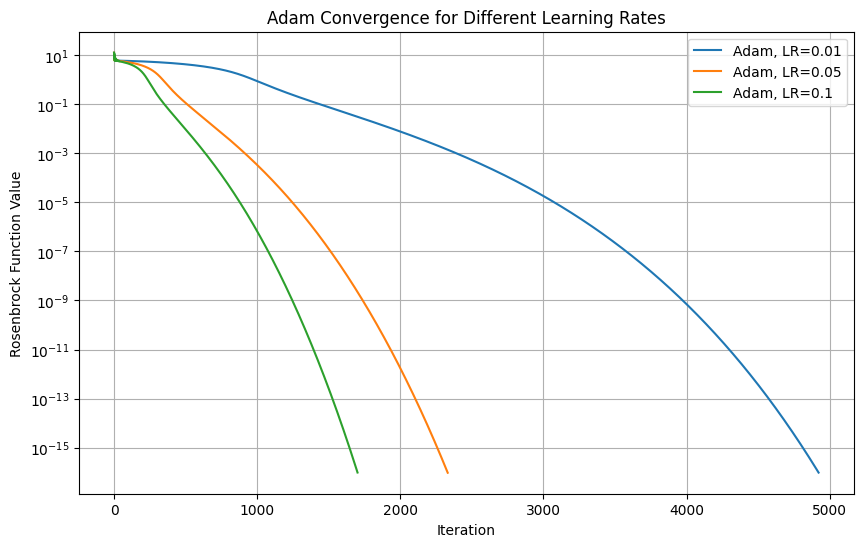

In [18]:
# ============================================
# Adam Convergence Comparison
# ============================================

plt.figure(figsize=(10, 6))

for row in results:

    if row["Optimizer"] == "Adam":

        history = np.array(row["History"], dtype=float)

        # Keep only positive finite values for log scale
        valid_history = history[
            np.isfinite(history) & (history > 0)
        ]

        plt.plot(
            valid_history,
            label=f"Adam, LR={row['Learning Rate']}"
        )

plt.xlabel("Iteration")
plt.ylabel("Rosenbrock Function Value")
plt.title("Adam Convergence for Different Learning Rates")
plt.yscale("log")
plt.legend()
plt.grid(True)

plt.show()

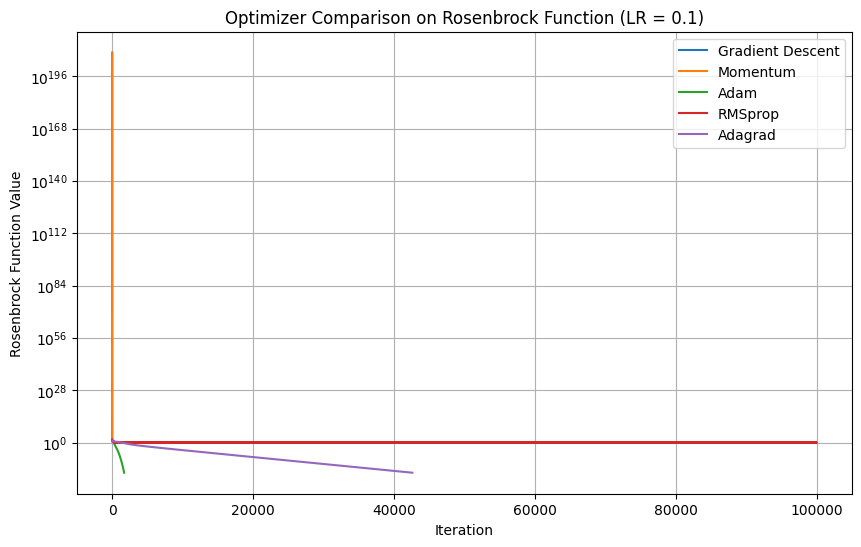

In [19]:
# ============================================
# Compare All Optimizers at LR = 0.1
# ============================================

fixed_lr = 0.1

plt.figure(figsize=(10, 6))

for row in results:

    if row["Learning Rate"] == fixed_lr:

        history = np.array(row["History"], dtype=float)

        # Keep only valid positive values
        valid_history = history[
            np.isfinite(history) & (history > 0)
        ]

        if len(valid_history) > 0:
            plt.plot(
                valid_history,
                label=row["Optimizer"]
            )

plt.xlabel("Iteration")
plt.ylabel("Rosenbrock Function Value")
plt.title("Optimizer Comparison on Rosenbrock Function (LR = 0.1)")
plt.yscale("log")
plt.legend()
plt.grid(True)

plt.show()

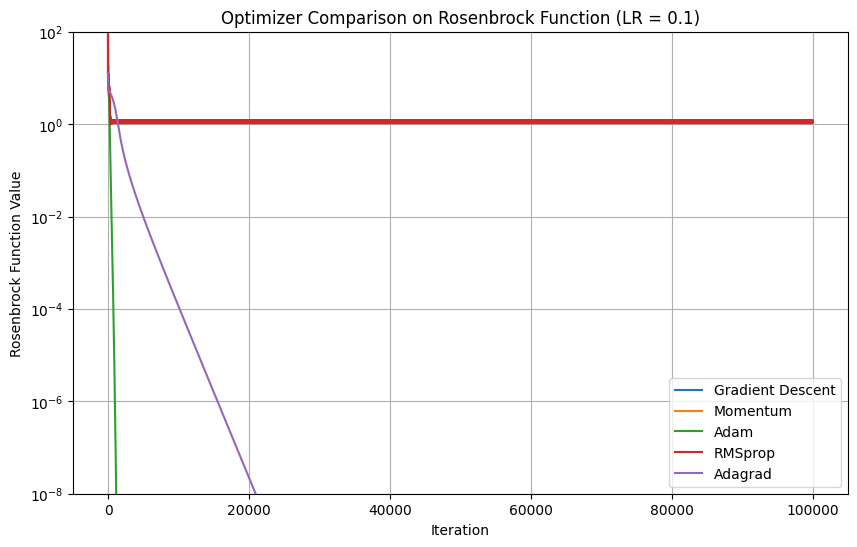

In [20]:
# ============================================
# Improved Optimizer Comparison
# Rosenbrock, Learning Rate = 0.1
# ============================================

fixed_lr = 0.1

plt.figure(figsize=(10, 6))

for row in results:

    if row["Learning Rate"] == fixed_lr:

        history = np.array(row["History"], dtype=float)

        # Remove invalid values
        history = history[np.isfinite(history)]

        if len(history) > 0:

            # Limit extremely large values only for visualization
            plot_history = np.minimum(history, 100)

            plt.plot(
                plot_history,
                label=row["Optimizer"]
            )

plt.xlabel("Iteration")
plt.ylabel("Rosenbrock Function Value")
plt.title("Optimizer Comparison on Rosenbrock Function (LR = 0.1)")

plt.yscale("log")
plt.ylim(1e-8, 100)

plt.legend()
plt.grid(True)

plt.show()

In [21]:
# ============================================
# 1D Simplified Ackley Function
# ============================================

def ackley(x):
    """
    1D simplified Ackley function:

    f(x) = -20 exp(-0.2 sqrt(x^2))
           - exp(cos(2*pi*x))
           + 20 + e
    """

    if x == 0:
        return 0.0

    return (
        -20 * np.exp(-0.2 * np.sqrt(x**2))
        - np.exp(np.cos(2 * np.pi * x))
        + 20
        + np.e
    )


# Test at the known global minimum
print("Ackley value at x = 0:", ackley(0))

Ackley value at x = 0: 0.0


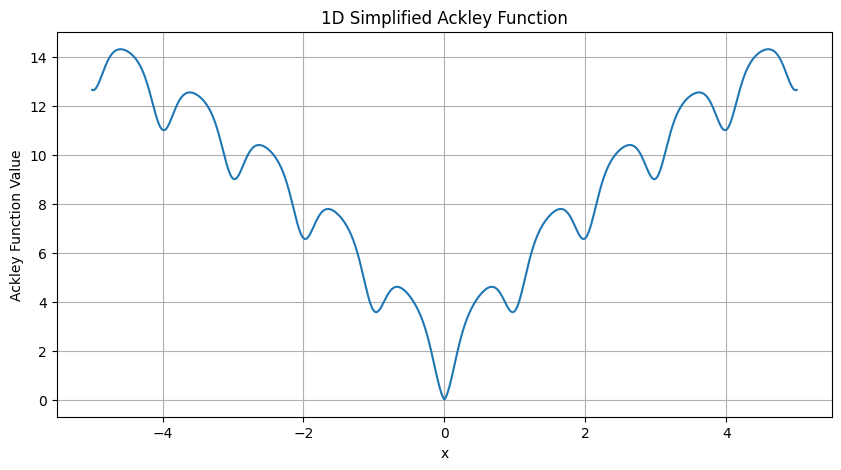

In [22]:
# ============================================
# Plot 1D Ackley Function
# ============================================

x_values = np.linspace(-5, 5, 1000)

y_values = np.array([
    ackley(x) for x in x_values
])

plt.figure(figsize=(10, 5))

plt.plot(x_values, y_values)

plt.xlabel("x")
plt.ylabel("Ackley Function Value")
plt.title("1D Simplified Ackley Function")

plt.grid(True)
plt.show()

In [23]:
# ============================================
# Gradient of 1D Ackley Function
# ============================================

def ackley_gradient(x):
    """
    Gradient of the 1D simplified Ackley function.

    For x != 0:

    f'(x) =
    4 sign(x) exp(-0.2|x|)
    + 2*pi*sin(2*pi*x)*exp(cos(2*pi*x))

    At x = 0, return 0.
    """

    if abs(x) < 1e-12:
        return 0.0

    first_term = (
        4
        * np.sign(x)
        * np.exp(-0.2 * abs(x))
    )

    second_term = (
        2
        * np.pi
        * np.sin(2 * np.pi * x)
        * np.exp(np.cos(2 * np.pi * x))
    )

    return first_term + second_term


# Test the gradient at the minimum
print("Gradient at x = 0:", ackley_gradient(0))

Gradient at x = 0: 0.0


In [24]:
# ============================================
# Improved Gradient Descent for Ackley
# ============================================

def gradient_descent_ackley(
    learning_rate,
    max_iterations=100000,
    tolerance=1e-8,
    x_start=2.0
):

    x = x_start

    history = []

    start_time = time.time()

    for iteration in range(max_iterations):

        # Current function value
        loss = ackley(x)
        history.append(loss)

        # Check whether we reached the global minimum
        if abs(x) < tolerance:
            x = 0.0
            break

        # Calculate gradient
        gradient = ackley_gradient(x)

        # Check gradient convergence
        if abs(gradient) < tolerance:
            break

        # Update x
        x = x - learning_rate * gradient

    end_time = time.time()

    return {
        "x": x,
        "function_value": ackley(x),
        "iterations": iteration + 1,
        "time": end_time - start_time,
        "history": history
    }

In [25]:
# ============================================
# Test Ackley Gradient Descent
# ============================================

ackley_gd_result = gradient_descent_ackley(
    learning_rate=0.001
)

print("Optimal x:", ackley_gd_result["x"])
print("Final function value:", ackley_gd_result["function_value"])
print("Iterations:", ackley_gd_result["iterations"])
print("Time taken:", ackley_gd_result["time"], "seconds")

Optimal x: 1.9744519865813357
Final function value: 6.559645375627877
Iterations: 182
Time taken: 0.0026624202728271484 seconds


In [26]:
# ============================================
# Test Improved Gradient Descent on Ackley
# ============================================

ackley_gd_result = gradient_descent_ackley(
    learning_rate=0.001
)

print("Optimal x:", ackley_gd_result["x"])
print("Final function value:", ackley_gd_result["function_value"])
print("Iterations:", ackley_gd_result["iterations"])
print("Time taken:", ackley_gd_result["time"], "seconds")

Optimal x: 1.9744519865813357
Final function value: 6.559645375627877
Iterations: 182
Time taken: 0.0027322769165039062 seconds


In [27]:
# ============================================
# Momentum Optimizer for Ackley
# ============================================

def momentum_ackley(
    learning_rate,
    beta=0.9,
    max_iterations=100000,
    tolerance=1e-8,
    x_start=2.0
):

    x = x_start

    # Initial velocity
    velocity = 0.0

    history = []

    start_time = time.time()

    for iteration in range(max_iterations):

        # Current function value
        loss = ackley(x)
        history.append(loss)

        # Check whether we reached the global minimum
        if abs(x) < tolerance:
            x = 0.0
            break

        # Calculate gradient
        gradient = ackley_gradient(x)

        # Check gradient convergence
        if abs(gradient) < tolerance:
            break

        # Update velocity
        velocity = beta * velocity + gradient

        # Update x
        x = x - learning_rate * velocity

    end_time = time.time()

    return {
        "x": x,
        "function_value": ackley(x),
        "iterations": iteration + 1,
        "time": end_time - start_time,
        "history": history
    }

In [28]:
# ============================================
# Test Momentum on Ackley
# ============================================

momentum_ackley_result = momentum_ackley(
    learning_rate=0.001
)

print("Optimal x:", momentum_ackley_result["x"])
print("Final function value:", momentum_ackley_result["function_value"])
print("Iterations:", momentum_ackley_result["iterations"])
print("Time taken:", momentum_ackley_result["time"], "seconds")

Optimal x: 1.9744519865616308
Final function value: 6.559645375627877
Iterations: 258
Time taken: 0.005563020706176758 seconds


In [29]:
# ============================================
# Adam Optimizer for Ackley
# ============================================

def adam_ackley(
    learning_rate,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-8,
    max_iterations=100000,
    tolerance=1e-8,
    x_start=2.0
):

    x = x_start

    # First moment
    m = 0.0

    # Second moment
    v = 0.0

    history = []

    start_time = time.time()

    for iteration in range(1, max_iterations + 1):

        # Current function value
        loss = ackley(x)
        history.append(loss)

        # Check whether we reached the global minimum
        if abs(x) < tolerance:
            x = 0.0
            break

        # Calculate gradient
        gradient = ackley_gradient(x)

        # Check gradient convergence
        if abs(gradient) < tolerance:
            break

        # Update first moment
        m = beta1 * m + (1 - beta1) * gradient

        # Update second moment
        v = beta2 * v + (1 - beta2) * (gradient ** 2)

        # Bias correction
        m_hat = m / (1 - beta1 ** iteration)
        v_hat = v / (1 - beta2 ** iteration)

        # Update x
        update = (
            learning_rate
            * m_hat
            / (np.sqrt(v_hat) + epsilon)
        )

        x = x - update

    end_time = time.time()

    return {
        "x": x,
        "function_value": ackley(x),
        "iterations": iteration,
        "time": end_time - start_time,
        "history": history
    }

In [30]:
# ============================================
# Test Adam on Ackley
# ============================================

adam_ackley_result = adam_ackley(
    learning_rate=0.001
)

print("Optimal x:", adam_ackley_result["x"])
print("Final function value:", adam_ackley_result["function_value"])
print("Iterations:", adam_ackley_result["iterations"])
print("Time taken:", adam_ackley_result["time"], "seconds")

Optimal x: 1.974451986399221
Final function value: 6.559645375627877
Iterations: 320
Time taken: 0.0063059329986572266 seconds


In [31]:
# ============================================
# RMSprop Optimizer for Ackley
# ============================================

def rmsprop_ackley(
    learning_rate,
    beta=0.9,
    epsilon=1e-8,
    max_iterations=100000,
    tolerance=1e-8,
    x_start=2.0
):

    x = x_start

    # Moving average of squared gradients
    squared_gradient_average = 0.0

    history = []

    start_time = time.time()

    for iteration in range(max_iterations):

        # Current function value
        loss = ackley(x)
        history.append(loss)

        # Check whether we reached the global minimum
        if abs(x) < tolerance:
            x = 0.0
            break

        # Calculate gradient
        gradient = ackley_gradient(x)

        # Check gradient convergence
        if abs(gradient) < tolerance:
            break

        # Update moving average
        squared_gradient_average = (
            beta * squared_gradient_average
            + (1 - beta) * gradient**2
        )

        # Calculate update
        update = (
            learning_rate
            * gradient
            / (
                np.sqrt(squared_gradient_average)
                + epsilon
            )
        )

        # Update x
        x = x - update

    end_time = time.time()

    return {
        "x": x,
        "function_value": ackley(x),
        "iterations": iteration + 1,
        "time": end_time - start_time,
        "history": history
    }

In [32]:
# ============================================
# Test RMSprop on Ackley
# ============================================

rmsprop_ackley_result = rmsprop_ackley(
    learning_rate=0.001
)

print("Optimal x:", rmsprop_ackley_result["x"])
print("Final function value:", rmsprop_ackley_result["function_value"])
print("Iterations:", rmsprop_ackley_result["iterations"])
print("Time taken:", rmsprop_ackley_result["time"], "seconds")

Optimal x: 1.97445198653358
Final function value: 6.559645375627877
Iterations: 61
Time taken: 0.0010809898376464844 seconds


In [33]:
# ============================================
# Adagrad Optimizer for Ackley
# ============================================
import time

def adagrad_ackley(
    learning_rate,
    epsilon=1e-8,
    max_iterations=100000,
    tolerance=1e-8,
    x_start=2.0
):

    x = x_start

    # Accumulated squared gradients
    accumulated_gradient = 0.0

    history = []

    start_time = time.time()

    for iteration in range(max_iterations):

        # Current function value
        loss = ackley(x)
        history.append(loss)

        # Check whether we reached the global minimum
        if abs(x) < tolerance:
            x = 0.0
            break

        # Calculate gradient
        gradient = ackley_gradient(x)

        # Check gradient convergence
        if abs(gradient) < tolerance:
            break

        # Accumulate squared gradient
        accumulated_gradient += gradient**2

        # Update x
        x = x - (
            learning_rate
            * gradient
            / (np.sqrt(accumulated_gradient) + epsilon)
        )

    end_time = time.time()

    return {
        "x": x,
        "function_value": ackley(x),
        "iterations": iteration + 1,
        "time": end_time - start_time,
        "history": history
    }

In [34]:
# ============================================
# Test Adagrad on Ackley
# ============================================

adagrad_ackley_result = adagrad_ackley(
    learning_rate=0.001
)

print("Optimal x:", adagrad_ackley_result["x"])
print("Final function value:", adagrad_ackley_result["function_value"])
print("Iterations:", adagrad_ackley_result["iterations"])
print("Time taken:", adagrad_ackley_result["time"], "seconds")

Optimal x: 1.9744519865827541
Final function value: 6.559645375627877
Iterations: 3502
Time taken: 0.07797765731811523 seconds


In [35]:
# ============================================
# 1D Simplified Ackley Function
# ============================================

def ackley(x):

    if x == 0:
        return 0.0

    return (
        -20 * np.exp(-0.2 * np.sqrt(x**2))
        - np.exp(np.cos(2 * np.pi * x))
        + 20
        + np.e
    )

In [36]:
# ============================================
# Gradient of 1D Ackley Function
# ============================================

def ackley_gradient(x):

    if abs(x) < 1e-12:
        return 0.0

    first_term = (
        4
        * np.sign(x)
        * np.exp(-0.2 * abs(x))
    )

    second_term = (
        2
        * np.pi
        * np.sin(2 * np.pi * x)
        * np.exp(np.cos(2 * np.pi * x))
    )

    return first_term + second_term

In [37]:
import numpy as np
import time

In [38]:
adagrad_ackley_result = adagrad_ackley(
    learning_rate=0.001
)

print("Optimal x:", adagrad_ackley_result["x"])
print("Final function value:", adagrad_ackley_result["function_value"])
print("Iterations:", adagrad_ackley_result["iterations"])
print("Time taken:", adagrad_ackley_result["time"], "seconds")

Optimal x: 1.9744519865827541
Final function value: 6.559645375627877
Iterations: 3502
Time taken: 0.06578946113586426 seconds


In [39]:
# ============================================
# Ackley Optimizers
# ============================================

ackley_optimizers = {
    "Gradient Descent": gradient_descent_ackley,
    "Momentum": momentum_ackley,
    "Adam": adam_ackley,
    "RMSprop": rmsprop_ackley,
    "Adagrad": adagrad_ackley
}

ackley_learning_rates = [0.01, 0.05, 0.1]

print("Ackley optimizers loaded:")
for name in ackley_optimizers:
    print("-", name)

print("Learning rates:", ackley_learning_rates)

Ackley optimizers loaded:
- Gradient Descent
- Momentum
- Adam
- RMSprop
- Adagrad
Learning rates: [0.01, 0.05, 0.1]


In [40]:
import numpy as np
import time

In [41]:
def ackley(x):
    if x == 0:
        return 0.0

    return (
        -20 * np.exp(-0.2 * np.sqrt(x**2))
        - np.exp(np.cos(2 * np.pi * x))
        + 20
        + np.e
    )

In [42]:
def ackley_gradient(x):

    if abs(x) < 1e-12:
        return 0.0

    first_term = (
        4
        * np.sign(x)
        * np.exp(-0.2 * abs(x))
    )

    second_term = (
        2
        * np.pi
        * np.sin(2 * np.pi * x)
        * np.exp(np.cos(2 * np.pi * x))
    )

    return first_term + second_term

In [43]:
# ============================================
# Full Ackley Experiment
# 5 Optimizers × 3 Learning Rates
# ============================================

ackley_optimizers = {
    "Gradient Descent": gradient_descent_ackley,
    "Momentum": momentum_ackley,
    "Adam": adam_ackley,
    "RMSprop": rmsprop_ackley,
    "Adagrad": adagrad_ackley
}

ackley_learning_rates = [0.01, 0.05, 0.1]

ackley_results = []

for optimizer_name, optimizer_function in ackley_optimizers.items():

    for lr in ackley_learning_rates:

        print(f"Running {optimizer_name} with learning rate = {lr}")

        result = optimizer_function(
            learning_rate=lr,
            x_start=2.0
        )

        # Determine status
        if (
            np.isfinite(result["x"])
            and np.isfinite(result["function_value"])
        ):
            status = "Completed"
        else:
            status = "Diverged"

        ackley_results.append({
            "Optimizer": optimizer_name,
            "Learning Rate": lr,
            "x": result["x"],
            "Final Function Value": result["function_value"],
            "Iterations": result["iterations"],
            "Time (seconds)": result["time"],
            "Status": status,
            "History": result["history"]
        })

print("\nAll Ackley experiments completed!")

Running Gradient Descent with learning rate = 0.01
Running Gradient Descent with learning rate = 0.05
Running Gradient Descent with learning rate = 0.1
Running Momentum with learning rate = 0.01
Running Momentum with learning rate = 0.05
Running Momentum with learning rate = 0.1
Running Adam with learning rate = 0.01
Running Adam with learning rate = 0.05
Running Adam with learning rate = 0.1
Running RMSprop with learning rate = 0.01
Running RMSprop with learning rate = 0.05
Running RMSprop with learning rate = 0.1
Running Adagrad with learning rate = 0.01
Running Adagrad with learning rate = 0.05
Running Adagrad with learning rate = 0.1

All Ackley experiments completed!


In [44]:
# ============================================
# Display Ackley Results
# ============================================

ackley_results_table = pd.DataFrame(ackley_results)

display(
    ackley_results_table[
        [
            "Optimizer",
            "Learning Rate",
            "x",
            "Final Function Value",
            "Iterations",
            "Time (seconds)",
            "Status"
        ]
    ]
)

,Optimizer,Learning Rate,x,Final Function Value,Iterations,Time (seconds),Status
0,Gradient Descent,0.01,1.974452,6.559645,6,0.000168,Completed
1,Gradient Descent,0.05,-0.398887,3.804705,100000,1.479162,Completed
2,Gradient Descent,0.10,0.876851,3.890592,100000,2.682280,Completed
3,Momentum,0.01,1.974452,6.559645,257,0.009815,Completed
4,Momentum,0.05,19.881060,20.260769,100000,1.849926,Completed
5,Momentum,0.10,1907.530669,22.343530,100000,1.495523,Completed
6,Adam,0.01,1.974452,6.559645,296,0.005458,Completed
7,Adam,0.05,1.974452,6.559645,330,0.005599,Completed
8,Adam,0.10,1.974452,6.559645,346,0.005904,Completed
9,RMSprop,0.01,1.979400,6.560894,100000,1.686954,Completed


In [45]:
# ============================================
# Correct Ackley Status
# ============================================

for row in ackley_results:

    x = row["x"]
    f = row["Final Function Value"]
    iterations = row["Iterations"]

    if abs(x) < 1e-6 and abs(f) < 1e-8:
        row["Status"] = "Global Minimum"

    elif iterations >= 100000:
        row["Status"] = "Max Iterations"

    else:
        row["Status"] = "Local Minimum / Stopped"

In [46]:
display(
    pd.DataFrame(ackley_results)[
        [
            "Optimizer",
            "Learning Rate",
            "x",
            "Final Function Value",
            "Iterations",
            "Time (seconds)",
            "Status"
        ]
    ]
)

,Optimizer,Learning Rate,x,Final Function Value,Iterations,Time (seconds),Status
0,Gradient Descent,0.01,1.974452,6.559645,6,0.000168,Local Minimum / Stopped
1,Gradient Descent,0.05,-0.398887,3.804705,100000,1.479162,Max Iterations
2,Gradient Descent,0.10,0.876851,3.890592,100000,2.682280,Max Iterations
3,Momentum,0.01,1.974452,6.559645,257,0.009815,Local Minimum / Stopped
4,Momentum,0.05,19.881060,20.260769,100000,1.849926,Max Iterations
5,Momentum,0.10,1907.530669,22.343530,100000,1.495523,Max Iterations
6,Adam,0.01,1.974452,6.559645,296,0.005458,Local Minimum / Stopped
7,Adam,0.05,1.974452,6.559645,330,0.005599,Local Minimum / Stopped
8,Adam,0.10,1.974452,6.559645,346,0.005904,Local Minimum / Stopped
9,RMSprop,0.01,1.979400,6.560894,100000,1.686954,Max Iterations


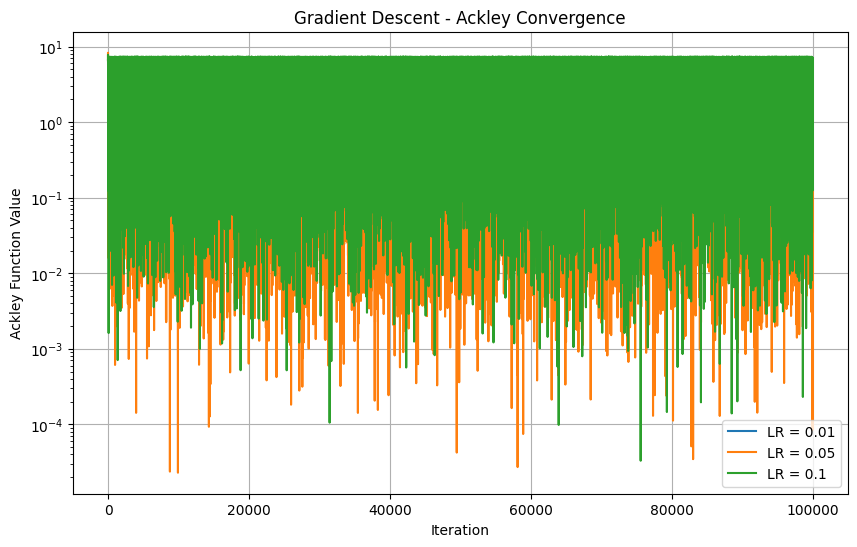

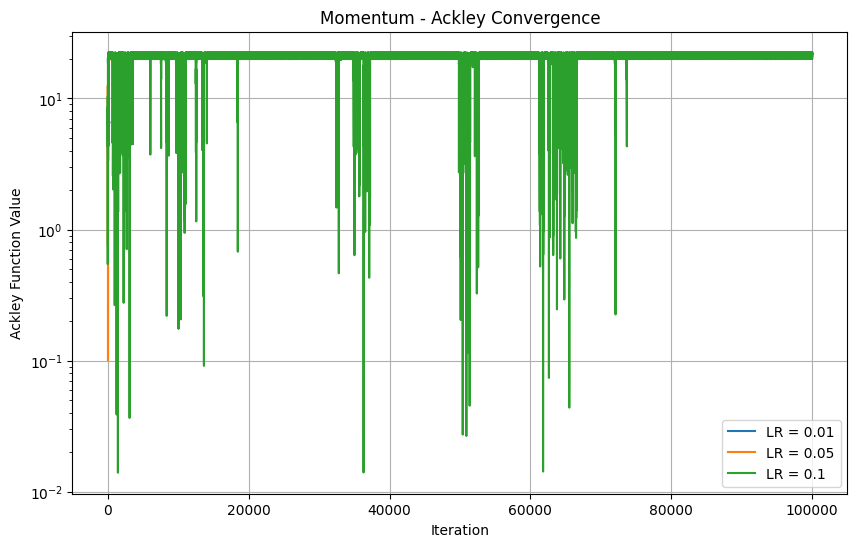

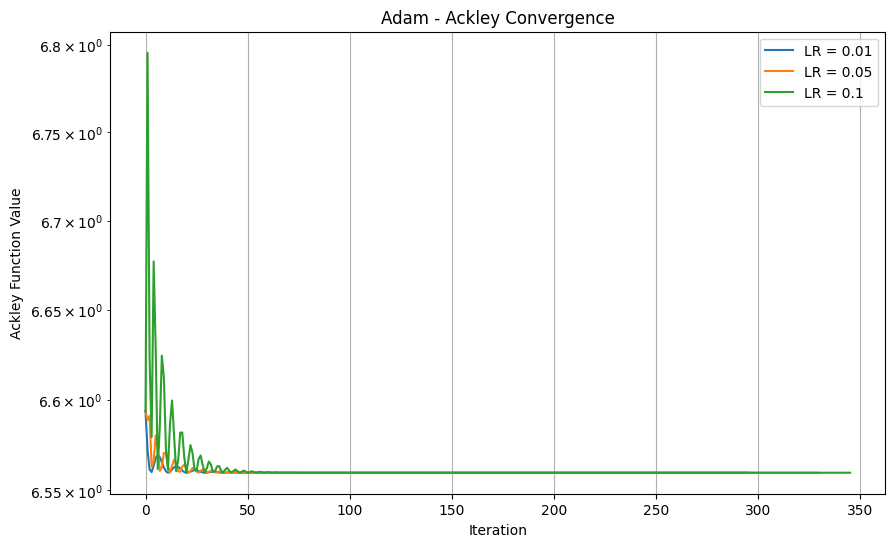

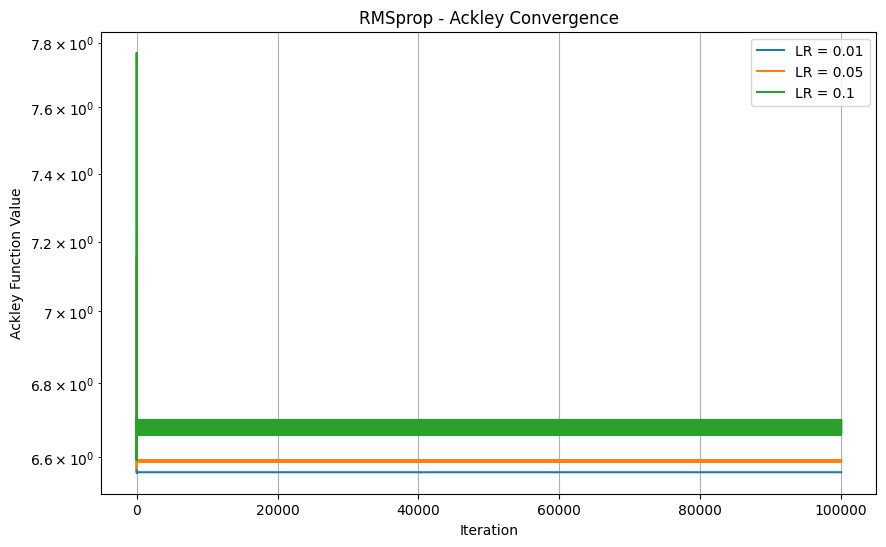

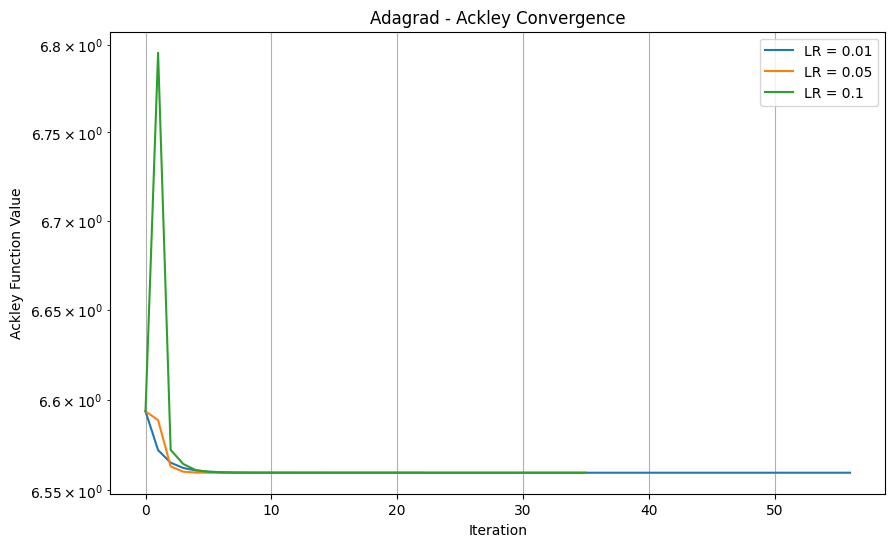

In [47]:
# ============================================
# Ackley Convergence Plots
# ============================================

for optimizer_name in ackley_optimizers:

    plt.figure(figsize=(10, 6))

    for row in ackley_results:

        if row["Optimizer"] == optimizer_name:

            history = np.array(row["History"], dtype=float)

            # Keep finite positive values for log scale
            valid_history = history[
                np.isfinite(history) & (history > 0)
            ]

            if len(valid_history) > 0:
                plt.plot(
                    valid_history,
                    label=f"LR = {row['Learning Rate']}"
                )

    plt.xlabel("Iteration")
    plt.ylabel("Ackley Function Value")
    plt.title(
        f"{optimizer_name} - Ackley Convergence"
    )

    plt.yscale("log")
    plt.legend()
    plt.grid(True)

    plt.show()

In [48]:
# ============================================
# Correct Ackley Status
# ============================================

for row in ackley_results:

    x = row["x"]
    f = row["Final Function Value"]
    iterations = row["Iterations"]

    if abs(x) < 1e-6 and abs(f) < 1e-8:
        row["Status"] = "Global Minimum"

    elif iterations >= 100000:
        row["Status"] = "Max Iterations"

    else:
        row["Status"] = "Local Minimum / Stopped"

In [49]:
# ============================================
# Corrected Ackley Results Table
# ============================================

ackley_corrected_table = pd.DataFrame(ackley_results)

display(
    ackley_corrected_table[
        [
            "Optimizer",
            "Learning Rate",
            "x",
            "Final Function Value",
            "Iterations",
            "Time (seconds)",
            "Status"
        ]
    ]
)

,Optimizer,Learning Rate,x,Final Function Value,Iterations,Time (seconds),Status
0,Gradient Descent,0.01,1.974452,6.559645,6,0.000168,Local Minimum / Stopped
1,Gradient Descent,0.05,-0.398887,3.804705,100000,1.479162,Max Iterations
2,Gradient Descent,0.10,0.876851,3.890592,100000,2.682280,Max Iterations
3,Momentum,0.01,1.974452,6.559645,257,0.009815,Local Minimum / Stopped
4,Momentum,0.05,19.881060,20.260769,100000,1.849926,Max Iterations
5,Momentum,0.10,1907.530669,22.343530,100000,1.495523,Max Iterations
6,Adam,0.01,1.974452,6.559645,296,0.005458,Local Minimum / Stopped
7,Adam,0.05,1.974452,6.559645,330,0.005599,Local Minimum / Stopped
8,Adam,0.10,1.974452,6.559645,346,0.005904,Local Minimum / Stopped
9,RMSprop,0.01,1.979400,6.560894,100000,1.686954,Max Iterations


In [50]:
# ============================================
# Ackley Best Results Summary
# ============================================

ackley_df = pd.DataFrame(ackley_results)

# Sort by final function value
ackley_best = ackley_df.sort_values(
    by="Final Function Value"
)

display(
    ackley_best[
        [
            "Optimizer",
            "Learning Rate",
            "x",
            "Final Function Value",
            "Iterations",
            "Time (seconds)",
            "Status"
        ]
    ].head(15)
)

,Optimizer,Learning Rate,x,Final Function Value,Iterations,Time (seconds),Status
1,Gradient Descent,0.05,-0.398887,3.804705,100000,1.479162,Max Iterations
2,Gradient Descent,0.10,0.876851,3.890592,100000,2.682280,Max Iterations
0,Gradient Descent,0.01,1.974452,6.559645,6,0.000168,Local Minimum / Stopped
3,Momentum,0.01,1.974452,6.559645,257,0.009815,Local Minimum / Stopped
7,Adam,0.05,1.974452,6.559645,330,0.005599,Local Minimum / Stopped
13,Adagrad,0.05,1.974452,6.559645,23,0.000367,Local Minimum / Stopped
14,Adagrad,0.10,1.974452,6.559645,36,0.000577,Local Minimum / Stopped
8,Adam,0.10,1.974452,6.559645,346,0.005904,Local Minimum / Stopped
12,Adagrad,0.01,1.974452,6.559645,57,0.000976,Local Minimum / Stopped
6,Adam,0.01,1.974452,6.559645,296,0.005458,Local Minimum / Stopped


In [51]:
# ============================================
# Fastest Local Convergence
# ============================================

local_results = ackley_df[
    ackley_df["Status"] == "Local Minimum / Stopped"
]

fastest = local_results.loc[
    local_results["Iterations"].idxmin()
]

print("Fastest local convergence:")
print("Optimizer:", fastest["Optimizer"])
print("Learning Rate:", fastest["Learning Rate"])
print("Iterations:", fastest["Iterations"])
print("Final x:", fastest["x"])
print("Final Function Value:", fastest["Final Function Value"])

Fastest local convergence:
Optimizer: Gradient Descent
Learning Rate: 0.01
Iterations: 6
Final x: 1.9744519864519579
Final Function Value: 6.559645375627877


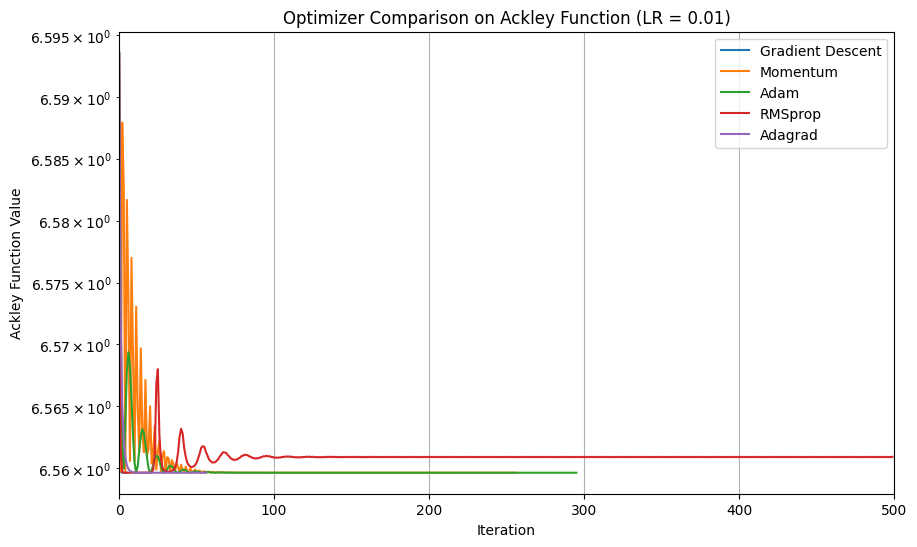

In [52]:
# ============================================
# Clean Ackley Optimizer Comparison
# LR = 0.01
# First 500 Iterations
# ============================================

plt.figure(figsize=(10, 6))

for optimizer_name in ackley_optimizers:

    rows = ackley_df[
        (ackley_df["Optimizer"] == optimizer_name) &
        (ackley_df["Learning Rate"] == 0.01)
    ]

    if len(rows) > 0:

        history = np.array(
            rows.iloc[0]["History"],
            dtype=float
        )

        # Only show first 500 iterations
        history = history[:500]

        valid = (
            np.isfinite(history) &
            (history > 0)
        )

        plt.plot(
            np.arange(len(history))[valid],
            history[valid],
            label=optimizer_name
        )

plt.xlabel("Iteration")
plt.ylabel("Ackley Function Value")
plt.title("Optimizer Comparison on Ackley Function (LR = 0.01)")

plt.yscale("log")
plt.xlim(0, 500)

plt.legend()
plt.grid(True)

plt.show()

In [53]:
# ============================================
# Display Rosenbrock Final Results
# ============================================

rosenbrock_df = pd.DataFrame(results)

display(rosenbrock_df)

,Optimizer,Learning Rate,x,y,Final Function Value,Iterations,Time (seconds),Status,History
0,Gradient Descent,0.01,NaN,NaN,NaN,100000,1.332963,Diverged,"[12.5, 624.653125, 794.4069480460065, 95307.15..."
1,Gradient Descent,0.05,NaN,NaN,NaN,100000,0.780417,Diverged,"[12.5, 119484.203125, 3.465299590704926e+16, 6..."
2,Gradient Descent,0.10,NaN,NaN,NaN,100000,0.699062,Diverged,"[12.5, 3572269.0, 1.2543302901446709e+22, 5.05..."
3,Momentum,0.01,NaN,NaN,NaN,100000,0.960071,Diverged,"[12.5, 624.653125, 3482.3203982890095, 3295971..."
4,Momentum,0.05,NaN,NaN,NaN,100000,0.968814,Diverged,"[12.5, 119484.203125, 3.4429444803464496e+16, ..."
5,Momentum,0.10,NaN,NaN,NaN,100000,0.957342,Diverged,"[12.5, 3572269.0, 1.2536690518538167e+22, 5.04..."
6,Adam,0.01,1.000000,1.000000,9.653323e-17,4923,0.147588,Converged/Completed,"[12.5, 10.614301000168048, 9.065595699989327, ..."
7,Adam,0.05,1.000000,1.000000,9.538441e-17,2332,0.052112,Converged/Completed,"[12.5, 6.278125000219035, 6.905827364412051, 8..."
8,Adam,0.10,1.000000,1.000000,9.723527e-17,1702,0.040410,Converged/Completed,"[12.5, 7.719999998965161, 11.447173567929603, ..."
9,RMSprop,0.01,0.980149,0.975543,2.245074e-02,100000,2.787429,Converged/Completed,"[12.5, 7.643132576375164, 6.4618937811363875, ..."


In [54]:
# ============================================
# TASK 2
# Multi-Layer Neural Network for Linear Regression
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

print("Libraries imported successfully!")

Libraries imported successfully!


TASK2


In [55]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
df = housing.frame

# Select the two required features and the target
X_raw = df[["MedInc", "HouseAge"]].values
y_raw = df[["MedHouseVal"]].values

print("Feature shape:", X_raw.shape)
print("Target shape:", y_raw.shape)
df[["MedInc", "HouseAge", "MedHouseVal"]].describe()

Feature shape: (20640, 2)
Target shape: (20640, 1)


,MedInc,HouseAge,MedHouseVal
count,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,2.068558
std,1.899822,12.585558,1.153956
min,0.499900,1.000000,0.149990
25%,2.563400,18.000000,1.196000
50%,3.534800,29.000000,1.797000
75%,4.743250,37.000000,2.647250
max,15.000100,52.000000,5.000010


In [56]:
def train_test_split_manual(X, y, test_size=0.2, seed=42):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    idx = rng.permutation(n)
    test_n = int(n * test_size)
    test_idx, train_idx = idx[:test_n], idx[test_n:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

# Standardize features (zero mean, unit variance) using train statistics only
X_train_raw, X_test_raw, y_train, y_test = train_test_split_manual(X_raw, y_raw)

X_mean = X_train_raw.mean(axis=0)
X_std = X_train_raw.std(axis=0)

X_train = (X_train_raw - X_mean) / X_std
X_test = (X_test_raw - X_mean) / X_std

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (16512, 2) Test shape: (4128, 2)


In [57]:
class NeuralNetwork:
    """
    Multi-layer neural network built from scratch (NumPy only).
    Supports GD, Momentum, and Adam optimizers, plus L2 regularization.
    layer_sizes: e.g. [2, 5, 3, 1] -> 2 inputs, hidden(5), hidden(3), output(1)
    ReLU on all hidden layers, linear (identity) on the output layer.
    """

    def __init__(self, layer_sizes, seed=42):
        self.layer_sizes = layer_sizes
        self.num_layers = len(layer_sizes) - 1
        rng = np.random.default_rng(seed)

        self.W, self.b = [], []
        for i in range(self.num_layers):
            fan_in, fan_out = layer_sizes[i], layer_sizes[i + 1]
            # He initialization (good default for ReLU networks)
            W = rng.normal(0, np.sqrt(2.0 / fan_in), size=(fan_in, fan_out))
            b = np.zeros((1, fan_out))
            self.W.append(W)
            self.b.append(b)

    def relu(self, z):
        return np.maximum(0, z)

    def relu_derivative(self, z):
        return (z > 0).astype(float)

    def forward(self, X):
        self.Z, self.A = [], [X]
        A = X
        for i in range(self.num_layers):
            Z = A @ self.W[i] + self.b[i]
            A = self.relu(Z) if i < self.num_layers - 1 else Z  # linear output
            self.Z.append(Z)
            self.A.append(A)
        return A

    def compute_loss(self, y_pred, y_true, l2_lambda=0.0):
        m = y_true.shape[0]
        mse = np.mean((y_pred - y_true) ** 2)
        if l2_lambda > 0:
            l2 = sum(np.sum(W ** 2) for W in self.W)
            mse += (l2_lambda / (2 * m)) * l2
        return mse

    def backward(self, X, y_true, l2_lambda=0.0):
        m = X.shape[0]
        y_pred = self.A[-1]
        dW, db = [None] * self.num_layers, [None] * self.num_layers

        dA = (2.0 / m) * (y_pred - y_true)  # dLoss/dOutput (MSE)
        for i in reversed(range(self.num_layers)):
            dZ = dA if i == self.num_layers - 1 else dA * self.relu_derivative(self.Z[i])
            dW[i] = self.A[i].T @ dZ + (l2_lambda / m) * self.W[i]
            db[i] = np.sum(dZ, axis=0, keepdims=True)
            if i > 0:
                dA = dZ @ self.W[i].T
        return dW, db

    def predict(self, X):
        return self.forward(X)

In [58]:
def train_network(nn, X, y, epochs=1000, learning_rate=0.01, optimizer="gd",
                   beta=0.9, beta1=0.9, beta2=0.999, epsilon=1e-8,
                   l2_lambda=0.0, verbose=False):

    vW = [np.zeros_like(W) for W in nn.W]   # momentum / adam 1st moment
    vb = [np.zeros_like(b) for b in nn.b]
    mW = [np.zeros_like(W) for W in nn.W]   # adam 2nd moment
    mb = [np.zeros_like(b) for b in nn.b]

    loss_history = []
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        y_pred = nn.forward(X)
        loss = nn.compute_loss(y_pred, y, l2_lambda)
        loss_history.append(loss)

        dW, db = nn.backward(X, y, l2_lambda)

        for i in range(nn.num_layers):
            if optimizer == "gd":
                nn.W[i] -= learning_rate * dW[i]
                nn.b[i] -= learning_rate * db[i]

            elif optimizer == "momentum":
                vW[i] = beta * vW[i] + (1 - beta) * dW[i]
                vb[i] = beta * vb[i] + (1 - beta) * db[i]
                nn.W[i] -= learning_rate * vW[i]
                nn.b[i] -= learning_rate * vb[i]

            elif optimizer == "adam":
                vW[i] = beta1 * vW[i] + (1 - beta1) * dW[i]
                vb[i] = beta1 * vb[i] + (1 - beta1) * db[i]
                mW[i] = beta2 * mW[i] + (1 - beta2) * (dW[i] ** 2)
                mb[i] = beta2 * mb[i] + (1 - beta2) * (db[i] ** 2)

                vW_hat = vW[i] / (1 - beta1 ** epoch)
                vb_hat = vb[i] / (1 - beta1 ** epoch)
                mW_hat = mW[i] / (1 - beta2 ** epoch)
                mb_hat = mb[i] / (1 - beta2 ** epoch)

                nn.W[i] -= learning_rate * vW_hat / (np.sqrt(mW_hat) + epsilon)
                nn.b[i] -= learning_rate * vb_hat / (np.sqrt(mb_hat) + epsilon)

        if verbose and epoch % 200 == 0:
            print(f"Epoch {epoch}: loss = {loss:.5f}")

    return {"loss_history": loss_history, "time": time.time() - start_time}

In [59]:
architecture = [2, 5, 3, 1]  # 2 inputs -> 5 -> 3 -> 1 output
optimizers = ["gd", "momentum", "adam"]
learning_rates = [0.01, 0.001]
epochs = 1000

task2_results = []

for opt in optimizers:
    for lr in learning_rates:
        print(f"Training with optimizer={opt}, lr={lr}")
        nn = NeuralNetwork(architecture, seed=42)
        out = train_network(nn, X_train, y_train, epochs=epochs,
                             learning_rate=lr, optimizer=opt)

        y_test_pred = nn.predict(X_test)
        test_mse = np.mean((y_test_pred - y_test) ** 2)

        task2_results.append({
            "Optimizer": opt,
            "Learning Rate": lr,
            "Final Train Loss": out["loss_history"][-1],
            "Test MSE": test_mse,
            "Time (s)": out["time"],
            "Model": nn,
            "History": out["loss_history"]
        })

print("\nAll Task 2 experiments completed!")

Training with optimizer=gd, lr=0.01
Training with optimizer=gd, lr=0.001
Training with optimizer=momentum, lr=0.01
Training with optimizer=momentum, lr=0.001
Training with optimizer=adam, lr=0.01
Training with optimizer=adam, lr=0.001

All Task 2 experiments completed!


In [61]:
task2_df = pd.DataFrame(task2_results)
display(task2_df[["Optimizer", "Learning Rate", "Final Train Loss", "Test MSE", "Time (s)"]])

,Optimizer,Learning Rate,Final Train Loss,Test MSE,Time (s)
0,gd,0.010,0.643613,0.640650,3.163557
1,gd,0.001,0.884363,0.863789,3.398937
2,momentum,0.010,0.643182,0.639392,5.582505
3,momentum,0.001,0.892823,0.871519,3.689860
4,adam,0.010,0.613737,0.615134,4.199540
5,adam,0.001,0.670351,0.666775,4.803667


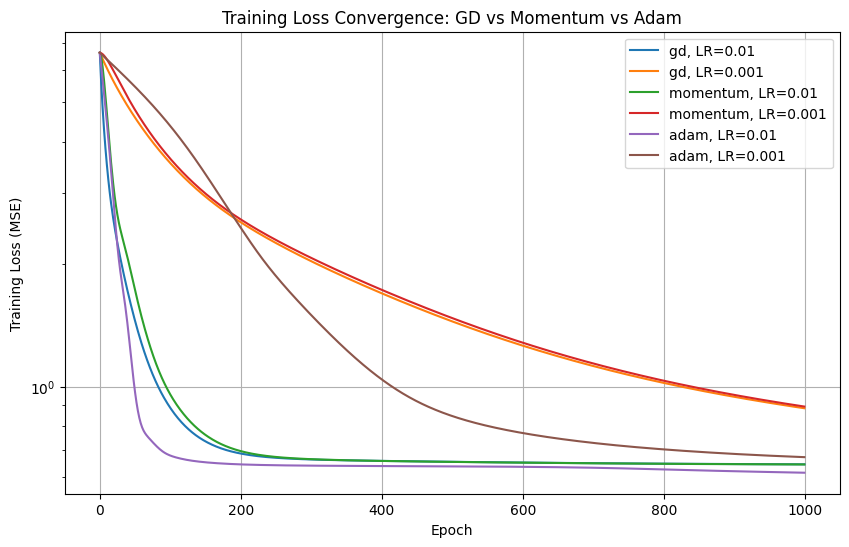

In [62]:
plt.figure(figsize=(10, 6))
for row in task2_results:
    plt.plot(row["History"], label=f"{row['Optimizer']}, LR={row['Learning Rate']}")

plt.xlabel("Epoch")
plt.ylabel("Training Loss (MSE)")
plt.title("Training Loss Convergence: GD vs Momentum vs Adam")
plt.yscale("log")
plt.legend()
plt.grid(True)
plt.show()

Best model: adam, LR=0.01, Test MSE=0.61513


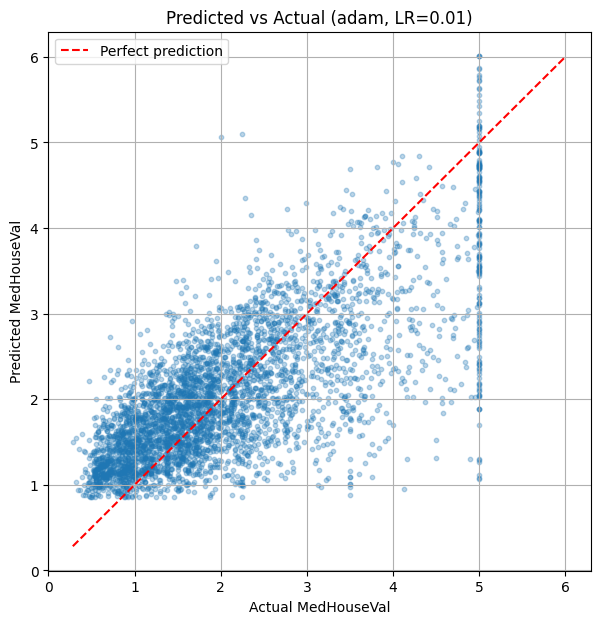

In [63]:
best_row = min(task2_results, key=lambda r: r["Test MSE"])
best_model = best_row["Model"]

print(f"Best model: {best_row['Optimizer']}, LR={best_row['Learning Rate']}, Test MSE={best_row['Test MSE']:.5f}")

y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_best, alpha=0.3, s=10)
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
plt.plot(lims, lims, 'r--', label="Perfect prediction")
plt.xlabel("Actual MedHouseVal")
plt.ylabel("Predicted MedHouseVal")
plt.title(f"Predicted vs Actual ({best_row['Optimizer']}, LR={best_row['Learning Rate']})")
plt.legend()
plt.grid(True)
plt.show()

2-hidden-layer network (best) Test MSE: 0.61513
3-hidden-layer network Test MSE:        0.69419


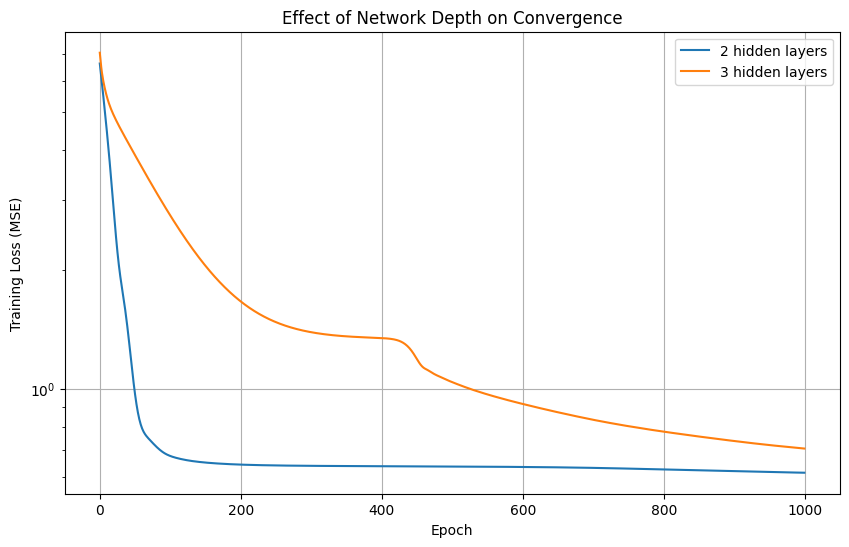

In [64]:
architecture_deep = [2, 5, 3, 2, 1]  # extra hidden layer with 2 neurons

nn_deep = NeuralNetwork(architecture_deep, seed=42)
out_deep = train_network(nn_deep, X_train, y_train, epochs=epochs,
                          learning_rate=0.01, optimizer="adam")

y_pred_deep = nn_deep.predict(X_test)
mse_deep = np.mean((y_pred_deep - y_test) ** 2)

print(f"2-hidden-layer network (best) Test MSE: {best_row['Test MSE']:.5f}")
print(f"3-hidden-layer network Test MSE:        {mse_deep:.5f}")

plt.figure(figsize=(10, 6))
plt.plot(best_row["History"], label="2 hidden layers")
plt.plot(out_deep["loss_history"], label="3 hidden layers")
plt.xlabel("Epoch"); plt.ylabel("Training Loss (MSE)")
plt.title("Effect of Network Depth on Convergence")
plt.yscale("log"); plt.legend(); plt.grid(True)
plt.show()

**Observation (Bonus 1 — extra hidden layer):** Adding a third hidden layer (2 neurons) *increased* test MSE from 0.615 to 0.694 rather than improving it. This is expected here: the model only has 2 input features (MedInc, HouseAge), so the underlying relationship it needs to learn is fairly simple and the 2-hidden-layer network already has more than enough capacity to capture it. Stacking another layer adds more parameters and a longer gradient path without adding useful representational power, which makes optimization slightly harder in the same 1000 epochs and shows up as a *worse*, not better, test score. This illustrates that deeper networks don't automatically generalize better — depth only helps when the data actually has extra complexity for it to model.

In [65]:
l2_lambdas = [0.0, 0.01, 0.1, 1.0]
l2_results = []

for l2 in l2_lambdas:
    nn_l2 = NeuralNetwork(architecture, seed=42)
    out_l2 = train_network(nn_l2, X_train, y_train, epochs=epochs,
                            learning_rate=0.01, optimizer="adam", l2_lambda=l2)

    y_pred_l2 = nn_l2.predict(X_test)
    train_mse = np.mean((nn_l2.predict(X_train) - y_train) ** 2)
    test_mse = np.mean((y_pred_l2 - y_test) ** 2)

    l2_results.append({"L2 Lambda": l2, "Train MSE": train_mse, "Test MSE": test_mse})
    print(f"L2={l2}: Train MSE={train_mse:.5f}, Test MSE={test_mse:.5f}")

pd.DataFrame(l2_results)

L2=0.0: Train MSE=0.61369, Test MSE=0.61513
L2=0.01: Train MSE=0.61522, Test MSE=0.61604
L2=0.1: Train MSE=0.61579, Test MSE=0.61616
L2=1.0: Train MSE=0.61530, Test MSE=0.61515


,L2 Lambda,Train MSE,Test MSE
0,0.00,0.613689,0.615134
1,0.01,0.615224,0.616043
2,0.10,0.615791,0.616165
3,1.00,0.615299,0.615148
